(70, 6)
     pl_name hostname  discoverymethod st_spectype  pl_eqt  pl_bmassj
3   DMPP-1 b   DMPP-1  Radial Velocity        F8 V   877.0   0.076362
5   DMPP-1 c   DMPP-1  Radial Velocity        F8 V  1239.0   0.030205
7   DMPP-1 d   DMPP-1  Radial Velocity        F8 V  1632.0   0.010540
8   DMPP-1 e   DMPP-1  Radial Velocity        F8 V  1314.0   0.012994
10  DMPP-2 b   DMPP-2  Radial Velocity        F5 V  1000.0   0.437000
         pl_name   hostname  discoverymethod st_spectype  pl_eqt  pl_bmassj
561   WASP-185 b   WASP-185          Transit        G0 V  1160.0      0.980
563   WASP-190 b   WASP-190          Transit     F6 IV-V  1500.0      1.000
568   WASP-192 b   WASP-192          Transit        G0 V  1620.0      2.300
572       XO-7 b       XO-7          Transit        G0 V  1743.0      0.709
581  eps Ind A b  eps Ind A  Radial Velocity        K5 V   275.0      6.310
Index(['pl_name', 'hostname', 'discoverymethod', 'st_spectype', 'pl_eqt',
       'pl_bmassj'],
      dtype='object')

<Figure size 800x600 with 0 Axes>

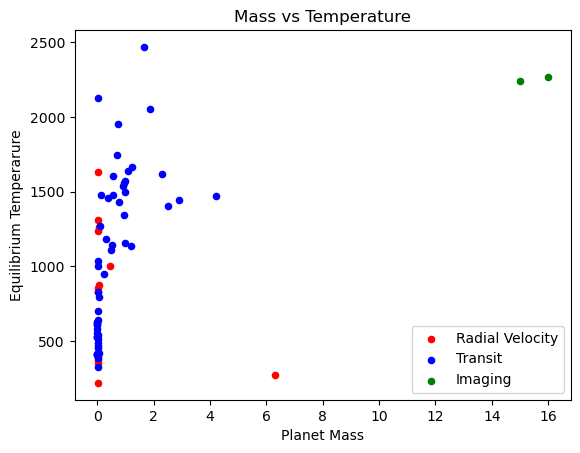

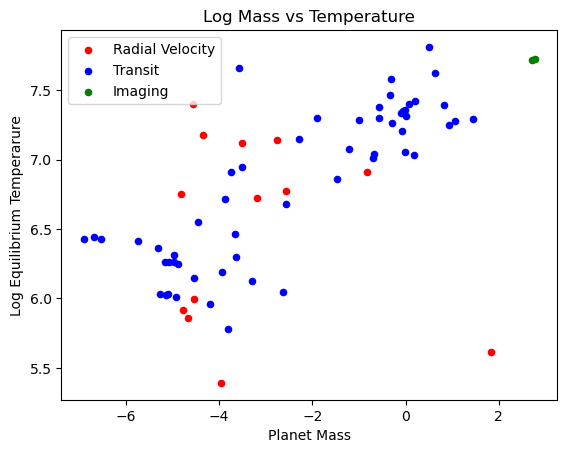

pl_name                eps Ind A b
hostname                 eps Ind A
discoverymethod    Radial Velocity
st_spectype                   K5 V
pl_eqt                       275.0
pl_bmassj                     6.31
log_mass                  1.842136
log_temp                  5.616771
Name: 581, dtype: object


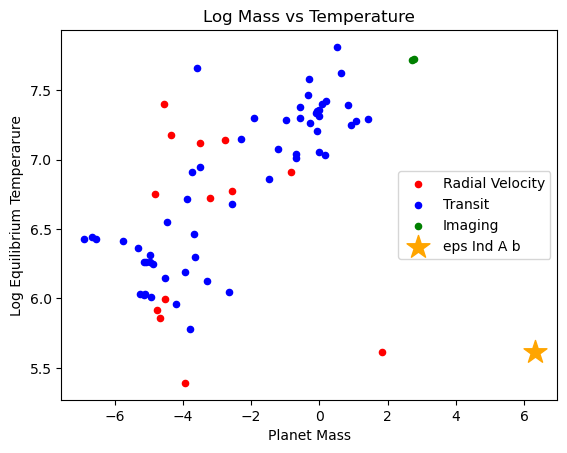

In [45]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd
df = pd.read_csv("../grace/homework8/exoplanet_data.csv", comment = "#")
#print(df)
#583 rows x 92 columns
#print(df.columns)
#I have no idea what these columns mean: st_tefflim,sy_vmagerr2,pl_orbpererr2,ttv_flag,st_metlim
#Planet Name, pl_name, name of the planet 
#Host Name, hostname, planet name and the star 
#Discovery Method, discoverymethod, how the planet was discovered 
#Spectral Type, st_spectype, spectral characteristics 
#Equilibrium Temperature [K], pl_eqt, equilibrium temp of the planet
#Planet Mass or Mass*sin(i) [Jupiter Mass], pl_bmassj, mass measured in jupiters mass 
small_df = df[["pl_name", "hostname", "discoverymethod", "st_spectype", "pl_eqt", "pl_bmassj"]]
small_df = small_df.dropna()
print(small_df.shape) #30 rows , 6 columns 
print(small_df.head())
print(small_df.tail())
print(small_df.columns)
print(small_df["discoverymethod"].value_counts()) 
#there are three discovery methods, 55 transit, 13 radial velocity, 2 imaging 
#transit has the most, and imaging has the least
#transit - mearuing the light as it passes
#radial velocity - measuring the impact of the gravitational puul of the planet on the host star 
#imaging - taking photos of the planet 
plt.figure(figsize=(8, 6))
ax = small_df[small_df["discoverymethod"] == "Radial Velocity"].plot.scatter(x="pl_bmassj", y="pl_eqt", color="red", label="Radial Velocity")
small_df[small_df["discoverymethod"] == "Transit"].plot.scatter(x="pl_bmassj", y="pl_eqt", color="blue", label="Transit", ax=ax)
small_df[small_df["discoverymethod"] == "Imaging"].plot.scatter(x="pl_bmassj", y="pl_eqt", color="green", label="Imaging", ax=ax)
plt.legend()
plt.title("Mass vs Temperature")
plt.ylabel("Equilibrium Temperarure")
plt.xlabel("Planet Mass")
plt.show()
small_df["log_mass"] = np.log(small_df["pl_bmassj"])
small_df["log_temp"] = np.log(small_df["pl_eqt"])
ax = small_df[small_df["discoverymethod"] == "Radial Velocity"].plot.scatter(x="log_mass", y="log_temp", color="red", label="Radial Velocity")
small_df[small_df["discoverymethod"] == "Transit"].plot.scatter(x="log_mass", y="log_temp", color="blue", label="Transit", ax=ax)
small_df[small_df["discoverymethod"] == "Imaging"].plot.scatter(x="log_mass", y="log_temp", color="green", label="Imaging", ax=ax)
plt.legend()
plt.title("Log Mass vs Temperature")
plt.ylabel("Log Equilibrium Temperarure")
plt.xlabel("Planet Mass")
plt.show()
#based on the plots the exoplanets found by imaging are more likeley to be large
coldest_planet = small_df[small_df["pl_bmassj"]>5].sort_values("pl_eqt").iloc[0]
print(coldest_planet)
#planet's name is eps Ind A b, at index 581, mass = 6.3, orbiting an orange dawrf dimmer than the sun 
small_df["log_mass"] = np.log(small_df["pl_bmassj"])
small_df["log_temp"] = np.log(small_df["pl_eqt"])
ax = small_df[small_df["discoverymethod"] == "Radial Velocity"].plot.scatter(x="log_mass", y="log_temp", color="red", label="Radial Velocity")
small_df[small_df["discoverymethod"] == "Transit"].plot.scatter(x="log_mass", y="log_temp", color="blue", label="Transit", ax=ax)
small_df[small_df["discoverymethod"] == "Imaging"].plot.scatter(x="log_mass", y="log_temp", color="green", label="Imaging", ax=ax)
plt.scatter(coldest_planet["pl_bmassj"], np.log(coldest_planet["pl_eqt"]), color = "orange", marker = "*", s=300, label = "eps Ind A b")
plt.legend()
plt.title("Log Mass vs Temperature")
plt.ylabel("Log Equilibrium Temperarure")
plt.xlabel("Planet Mass")
plt.show()
#title: A temperate super-Jupiter imaged with JWST in the mid-infrared
#abstract summary: JWST found a very bright very large planet
#yes it matches the data 
#it is special becasue of how large it is in comparison to how bright it is 
#both values match with the article 
